<a href="https://colab.research.google.com/github/quratulain-nayeem/shap/blob/master/text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `text` plot

This notebook is designed to demonstrate (and so document) how to use the `shap.plots.text` function. It uses a distilled PyTorch BERT model from the transformers package to do sentiment analysis of IMDB movie reviews.

Note that the prediction function we define takes a list of strings and returns a logit value for the positive class.

In [1]:
# install if needed (Colab)
# !pip install datasets transformers torch shap

import torch
import transformers
from datasets import load_dataset

import shap

# -----------------------------
# Load dataset
# -----------------------------
imdb_train = load_dataset("imdb")["train"]

# Optional: limit size for speed
imdb_train = imdb_train.select(range(100))

# -----------------------------
# Load model + tokenizer
# -----------------------------
tokenizer = transformers.DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

model = transformers.DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

# -----------------------------
# Device setup (GPU safe)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


# -----------------------------
# Prediction function
# -----------------------------
def f(x):
    x = [str(i) for i in x]  # safety fix

    inputs = tokenizer(x, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.nn.functional.softmax(logits, dim=-1)
    val = torch.log(probs[:, 1] / probs[:, 0])

    return val.cpu().numpy()


# -----------------------------
# SHAP Explainer
# -----------------------------
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(f, masker)

# -----------------------------
# Run explanation
# -----------------------------
texts = list(imdb_train[:10]["text"])
shap_values = explainer(texts, fixed_context=1)

# -----------------------------
# Plot
# -----------------------------
shap.plots.text(shap_values[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

PartitionExplainer explainer:  90%|█████████ | 9/10 [00:34<00:03,  3.64s/it]Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [00:45<00:00,  5.86s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [00:51,  5.69s/it]


## Single instance text plot

When we pass a single instance to the text plot we get the importance of each token overlayed on the original text that corresponds to that token. Red regions correspond to parts of the text that increase the output of the model when they are included, while blue regions decrease the output of the model when they are included. In the context of the sentiment analysis model here red corresponds to a more positive review and blue a more negative review.

Note that importance values returned for text models are often hierarchical and follow the structure of the text. Nonlinear interactions between groups of tokens are often saved and can be used during the plotting process. If the Explanation object passed to the text plot has a `.hierarchical_values` attribute, then small groups of tokens with strong non-linear effects among them will be auto-merged together to form coherent chunks. When the `.hierarchical_values` attribute is present it also means that the explainer may not have completely enumerated all possible token perturbations and so has treated chunks of the text as essentially a single unit. This happens since we often want to explain a text model while evaluating it fewer times than the numbers of tokens in the document. Whenever a region of the input text is not split by the explainer, it is show by the text plot as a single unit.

The force plot above the text is designed to provide an overview of how all the parts of the text combine to produce the model's output. See the [force plot]() notebook for more details, but the general structure of the plot is positive red features "pushing" the model output higher while negative blue features "push" the model output lower. The force plot provides much more quantitative information than the text coloring. Hovering over a chuck of text will underline the portion of the force plot that corresponds to that chunk of text, and hovering over a portion of the force plot will underline the corresponding chunk of text.

Note that clicking on any chunk of text will show the sum of the SHAP values attributed to the tokens in that chunk (clicked again will hide the value).

In [2]:
# plot the first sentence's explanation
shap.plots.text(shap_values[3])

## Multiple instance text plot

When we pass a multi-row explanation object to the text plot we get the single instance plots for each input instance scaled so they have consistent comparable x-axis and color ranges.

In [3]:
# plot the first sentence's explanation
shap.plots.text(shap_values[:3])

## Summarizing text explanations

While plotting several instance-level explanations using the text plot can be very informative, sometime you want global summaries of the impact of tokens over the a large set of instances. See the [Explanation object]() documentation for more details, but you can easily summarize the importance of tokens in a dataset by collapsing a multi-row explanation object over all it's rows (in this case by summing). Doing this treats every text input token type as a feature, so the collapsed Explanation object will have as many columns as there were unique tokens in the orignal multi-row explanation object. If there are hierarchical values present in the Explanation object then any large groups are divided up and each token in the gruop is given an equal share of the overall group importance value.

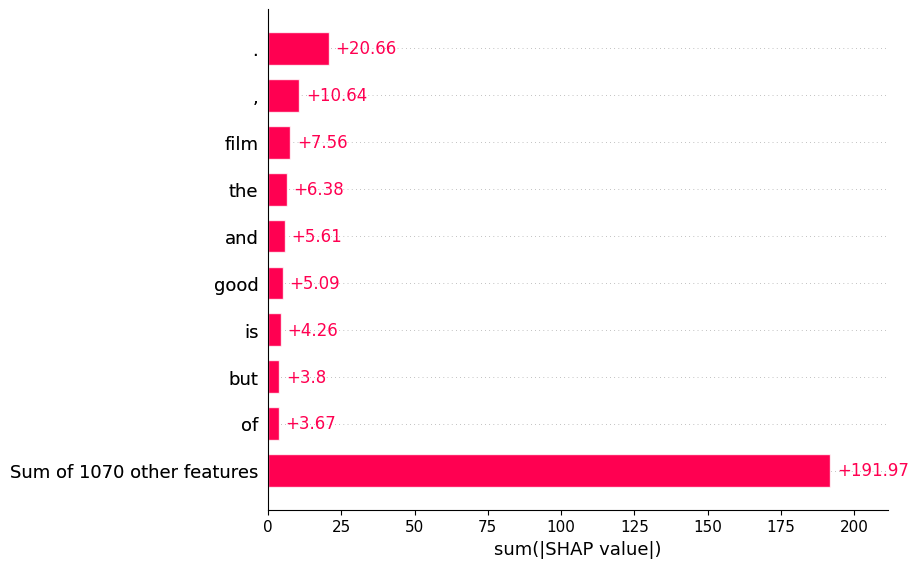

In [4]:
shap.plots.bar(shap_values.abs.sum(0))

Note that how you summarize the importance of features can make a big difference. In the plot above the `a` token was very importance both because it had an impact on the model, and because it was very common. Below we instead summize the instances using the `max` function to see the largest impact of a token in any instance.

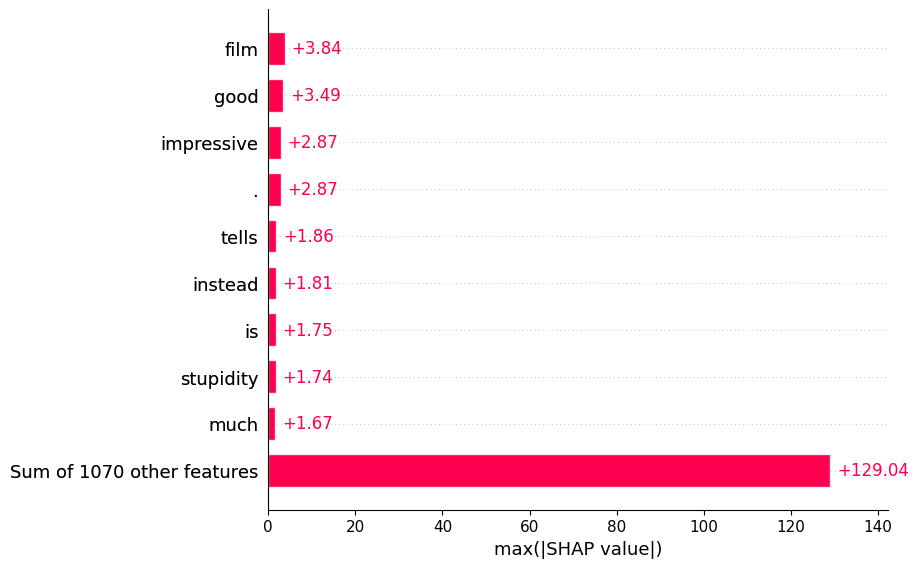

In [5]:
shap.plots.bar(shap_values.abs.max(0))

You can also slice out a single token from all the instances by using that token as an input name (note that the gray values to the left of the input names are the original text that the token was generated from).

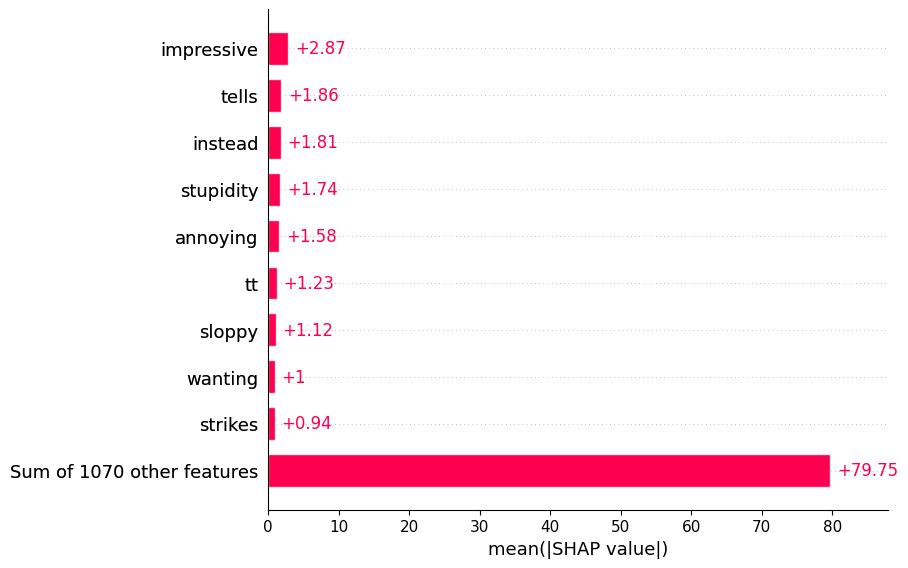

In [6]:
shap.plots.bar(shap_values)

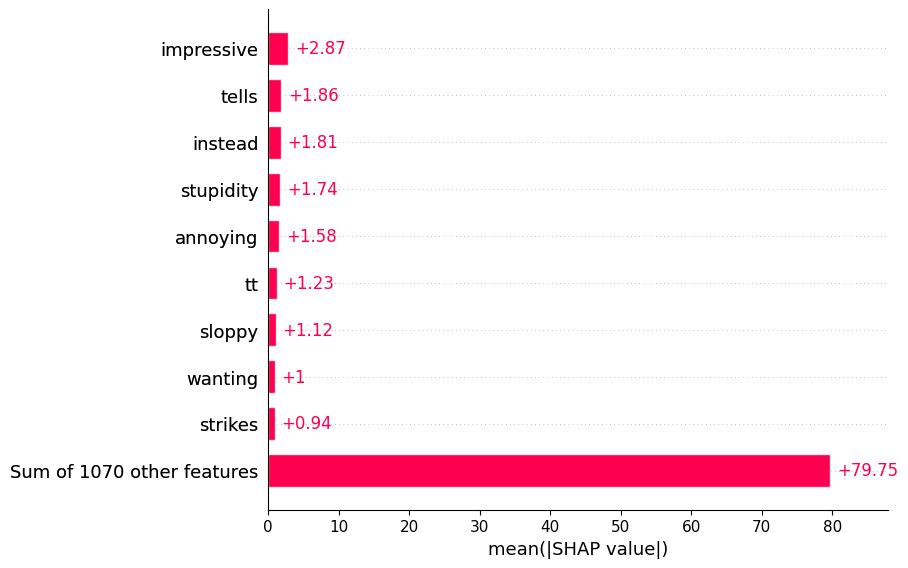

In [7]:
shap.plots.bar(shap_values)

## Text-To-Text Visualization

In [8]:
import torch

import shap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(f, masker)

s = ["In this picture, there are four persons."]
shap_values = explainer(s)

shap.plots.text(shap_values[0])

Text-To-Text Visualization contains the input text to the model on the left side and output text on the right side (in the default layout). On hovering over a token on the right (output) side the importance of each input token is overlayed on it, and is signified by the background color of the token. Red regions correspond to parts of the text that increase the output of the model when they are included, while blue regions decrease the output of the model when they are included. The explanation for a particular output token can be anchored by clickling on the output token (it can be un-anchored by clicking again).

Note that similar to the single output plots described above, importance values returned for text models are often hierarchical and follow the structure of the text. Small groups of tokens with strong non-linear effects among them will be auto-merged together to form coherent chunks. Similarly, The explainer may not have completely enumerated all possible token perturbations and so has treated chunks of the text as essentially a single unit. This preprocessing is done for each output token, and the merging behviour can differ for each output token, since the interation effects might be different for each output token. The merged chunks can be viewed by hovering over the input text, once an output token is anchored. All the tokens of a merged chunk are made bold.

Once the ouput text is anchored the input tokens can be clicked on to view the exact shap value (Hovering over input token also brings up a tooltip with the values). Auto merged tokens show the total values divided over the number of tokens in that chunk.

Hovering over the input text shows the SHAP value for that token for each output token. This is again signified by the background color of the output token. This can be anchored by clicking on the input token.

Note: The color scaling for all token (input and output) are consistent and the brightest red is assigned to the maximum SHAP value of input tokens for any output token.

Note: The layout of the two pieces of text can be changed by using the 'Layout' Drop down menu.

In [9]:
shap.plots.text(shap_values)

<hr>
Have an idea for more helpful examples? Pull requests that add to this documentation notebook are encouraged!